1. Bar Plot: Tingkat Interaksi Sosial dengan Performa Akademik
Pertanyaan: Bagaimana hubungan antara tingkat interaksi sosial dengan performa akademik remaja? Apakah ada pola yang jelas?

Jumlah data: 1200 baris
Nilai unik social_interaction_level: ['low' 'high' 'medium']
  social_interaction_level  rata_rata_akademik
0                      low            2.989398
1                   medium            2.998413
2                     high            2.982439


C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\3785131386.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_x, color='black', fontsize=12) # Changed from '#CCCCCC'


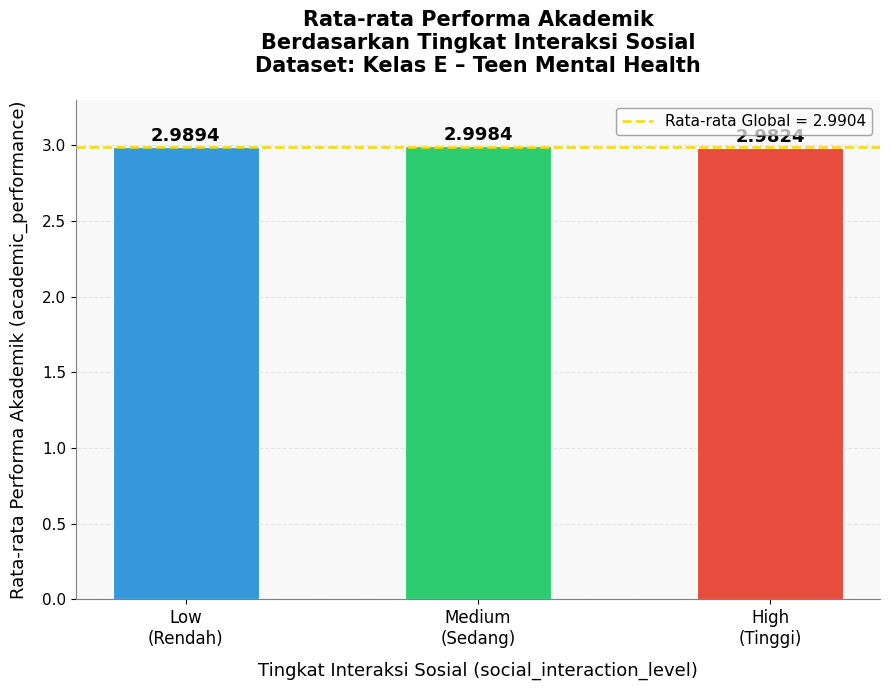

✅ Grafik berhasil disimpan!
       INTERPRETASI HASIL AGREGASI
  LOW      → Rata-rata GPA = 2.9894
  MEDIUM   → Rata-rata GPA = 2.9984
  HIGH     → Rata-rata GPA = 2.9824

  Rata-rata Global  → 2.9904

  GPA Tertinggi : kelompok 'medium'
  GPA Terendah  : kelompok 'high'

  Kesimpulan:
  Siswa dengan interaksi sosial 'medium' memiliki
  rata-rata performa akademik tertinggi dibanding
  kelompok interaksi sosial lainnya.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
df = pd.read_csv('Kelas E_Teen Mental Health.csv')
print(f'Jumlah data: {len(df)} baris')
print(f'Nilai unik social_interaction_level: {df["social_interaction_level"].unique()}')
# ----------------------------------------------------------
# 2. AGREGASI: Rata-rata academic_performance per social_interaction_level
# ----------------------------------------------------------
agregasi = df.groupby('social_interaction_level')['academic_performance'].mean().reset_index()
agregasi.columns = ['social_interaction_level', 'rata_rata_akademik']

# Urutkan: low → medium → high
urutan = ['low', 'medium', 'high']
agregasi['social_interaction_level'] = pd.Categorical(
    agregasi['social_interaction_level'],
    categories=urutan,
    ordered=True
)
agregasi = agregasi.sort_values('social_interaction_level').reset_index(drop=True)

print(agregasi)
# ----------------------------------------------------------
# 3. BAR CHART (GRAFIK 1 - KATEGORI A)
# Menggunakan pendekatan objek: ax = axes[x, y]
# ----------------------------------------------------------

warna = ['#3498DB', '#2ECC71', '#E74C3C']   # biru, hijau, merah
label_x = ['Low\n(Rendah)', 'Medium\n(Sedang)', 'High\n(Tinggi)']

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
fig.patch.set_facecolor('white') # Changed from '#0F0F1A'
ax.set_facecolor('#F8F8F8') # Changed from '#1A1A2E'

# Plot bar
bars = ax.bar(
    agregasi['social_interaction_level'],
    agregasi['rata_rata_akademik'],
    color=warna,
    width=0.5,
    edgecolor='white',
    linewidth=0.8,
    zorder=3
)

# Anotasi nilai di atas tiap bar
for bar, nilai in zip(bars, agregasi['rata_rata_akademik']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{nilai:.4f}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold',
        color='black' # Changed from 'white'
    )

# Garis rata-rata keseluruhan
rata_global = df['academic_performance'].mean()
ax.axhline(
    rata_global,
    color='#FFD700',
    linewidth=1.8,
    linestyle='--',
    label=f'Rata-rata Global = {rata_global:.4f}',
    zorder=4
)

# Label dan judul
ax.set_xlabel('Tingkat Interaksi Sosial (social_interaction_level)',
              fontsize=13, color='black', labelpad=10) # Changed from '#E0E0E0'
ax.set_ylabel('Rata-rata Performa Akademik (academic_performance)',
              fontsize=13, color='black', labelpad=10) # Changed from '#E0E0E0'
ax.set_title(
    'Rata-rata Performa Akademik\nBerdasarkan Tingkat Interaksi Sosial\n'
    'Dataset: Kelas E – Teen Mental Health',
    fontsize=15, color='black', fontweight='bold', pad=20 # Changed from 'white'
)

ax.set_xticklabels(label_x, color='black', fontsize=12) # Changed from '#CCCCCC'
ax.tick_params(axis='y', colors='black', labelsize=11) # Changed from '#CCCCCC'
ax.set_ylim(0, agregasi['rata_rata_akademik'].max() + 0.3)

ax.grid(axis='y', linestyle='--', alpha=0.5, color='lightgray', zorder=0) # Changed from 'white'
ax.spines['bottom'].set_color('gray') # Changed from '#444'
ax.spines['left'].set_color('gray') # Changed from '#444'
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=11, framealpha=0.7, facecolor='white',
          edgecolor='gray', labelcolor='black') # Changed from '#1A1A2E', '#555', 'white'

plt.tight_layout()
plt.savefig('bar_interaksi_sosial_akademik.png', dpi=150,
            bbox_inches='tight', facecolor='white') # Changed from '#0F0F1A'
plt.show()
print('✅ Grafik berhasil disimpan!')
# ----------------------------------------------------------
# 4. INTERPRETASI & KESIMPULAN
# ----------------------------------------------------------
print('=' * 55)
print('       INTERPRETASI HASIL AGREGASI')
print('=' * 55)
for _, row in agregasi.iterrows():
    print(f"  {row['social_interaction_level'].upper():<8} → Rata-rata GPA = {row['rata_rata_akademik']:.4f}")

print(f"\n  Rata-rata Global  → {rata_global:.4f}")

tertinggi = agregasi.loc[agregasi['rata_rata_akademik'].idxmax(), 'social_interaction_level']
terendah  = agregasi.loc[agregasi['rata_rata_akademik'].idxmin(), 'social_interaction_level']

print(f"\n  GPA Tertinggi : kelompok '{tertinggi}'")
print(f"  GPA Terendah  : kelompok '{terendah}'")
print()
print('  Kesimpulan:')
print(f"  Siswa dengan interaksi sosial '{tertinggi}' memiliki")
print('  rata-rata performa akademik tertinggi dibanding')
print('  kelompok interaksi sosial lainnya.')
print('=' * 55)

2. Line Plot: Pengaruh Pola Tidur pada Kesejahteraan Mental
Pertanyaan: Bagaimana pola tidur remaja mempengaruhi tingkat stres dan kecemasan mereka?

Total data: 1200 baris
Jumlah data setelah filter: 36 baris
    age  gender  physical_activity  addiction_level platform_usage
0    13  female                0.4                9      Instagram
1    14  female                0.3                8      Instagram
2    14  female                0.1                8           Both
3    17  female                0.0                8      Instagram
4    15  female                0.4                8      Instagram
5    13  female                0.2                9      Instagram
6    16  female                0.1                9      Instagram
7    13  female                0.3                8         TikTok
8    16  female                0.0               10           Both
9    13  female                0.2                8      Instagram
10   18  female                0.3                9           Both
11   19  female                0.4                8         TikTok
12   13  female                0.1                9           Both
13

C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\1310003455.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tren_platform['platform_usage'],


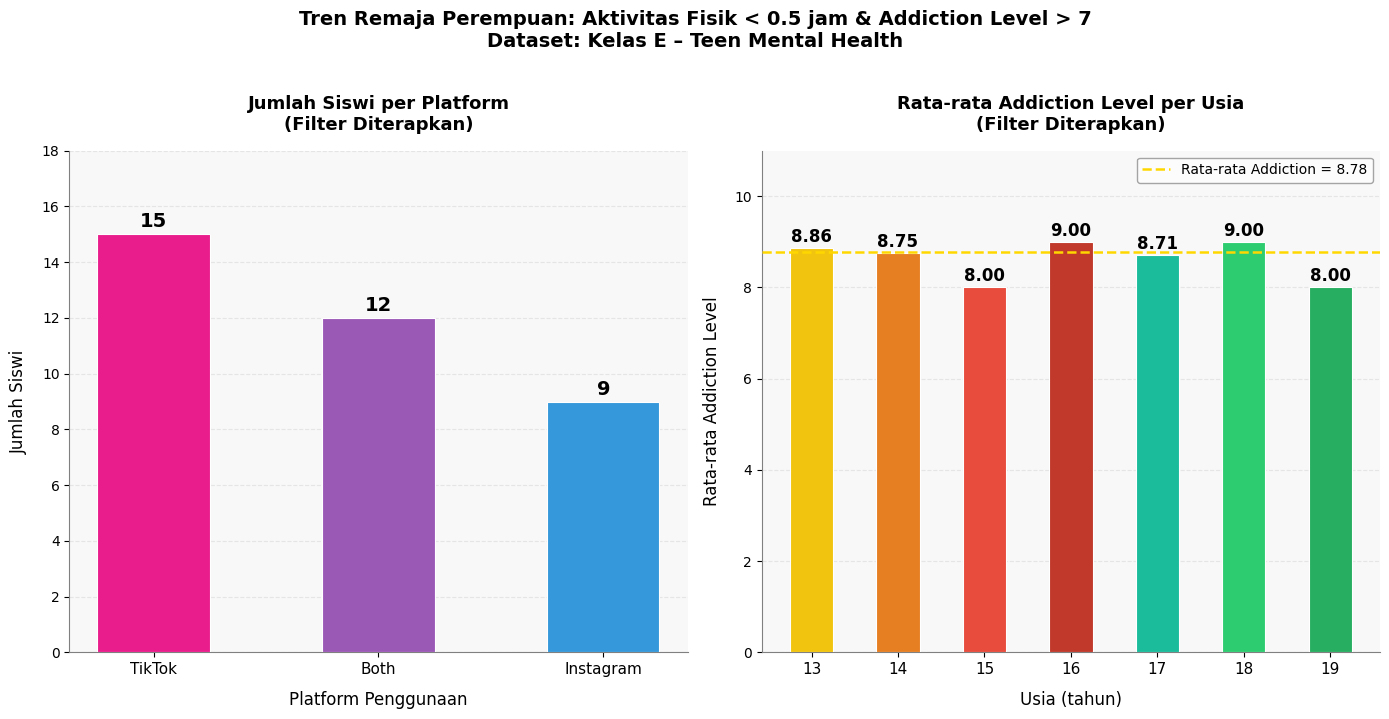

✅ Grafik berhasil disimpan!
       INTERPRETASI HASIL TREN / FILTER
  Filter yang diterapkan:
  • gender           == female
  • physical_activity < 0.5 jam
  • addiction_level  > 7

  Total siswi terfilter : 36 orang
  Rata-rata addiction   : 8.78
  Rata-rata fisik       : 0.23 jam

  Platform terbanyak  : TikTok (15 siswi)
  Usia addiction tertinggi: 16 tahun (rata-rata 9.00)

  Kesimpulan:
  Siswi dengan aktivitas fisik sangat rendah cenderung
  memiliki tingkat kecanduan media sosial yang tinggi.
  Tren ini terlihat merata di various kelompok usia.


In [4]:
# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
df = pd.read_csv('Kelas E_Teen Mental Health.csv')
print(f'Total data: {len(df)} baris')
# ----------------------------------------------------------
# 2. FILTER DATA (Tren / Filter)
# ----------------------------------------------------------
df_filter = df[
    (df['gender'] == 'female') &
    (df['physical_activity'] < 0.5) &
    (df['addiction_level'] > 7)
].reset_index(drop=True)

print(f'Jumlah data setelah filter: {len(df_filter)} baris')
print(df_filter[['age', 'gender', 'physical_activity',
                  'addiction_level', 'platform_usage']].to_string())
# ----------------------------------------------------------
# 3. AGREGASI: Jumlah siswi per platform & addiction_level
# ----------------------------------------------------------
# Tren jumlah siswi per platform penggunaan
tren_platform = df_filter.groupby('platform_usage').size().reset_index()
tren_platform.columns = ['platform_usage', 'jumlah']
tren_platform = tren_platform.sort_values('jumlah', ascending=False).reset_index(drop=True)

# Tren rata-rata addiction_level per usia
tren_usia = df_filter.groupby('age')['addiction_level'].mean().reset_index()
tren_usia.columns = ['age', 'rata_addiction']

print('\nJumlah siswi per platform:')
print(tren_platform)
print('\nRata-rata addiction per usia:')
print(tren_usia)
# ----------------------------------------------------------
# 4. BAR CHART (GRAFIK 2 - KATEGORI B)
# Menggunakan pendekatan objek: ax = axes[x, y]
# Dua bar chart dalam satu figure untuk menampilkan tren
# ----------------------------------------------------------

warna_platform = ['#E91E8C', '#9B59B6', '#3498DB']
warna_usia     = ['#F1C40F', '#E67E22', '#E74C3C',
                  '#C0392B', '#1ABC9C', '#2ECC71', '#27AE60']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white') # Changed from '#0F0F1A'

# ── Bar Chart Kiri: Jumlah siswi per platform ──
ax = axes[0]
ax.set_facecolor('#F8F8F8') # Changed from '#1A1A2E'

bars1 = ax.bar(
    tren_platform['platform_usage'],
    tren_platform['jumlah'],
    color=warna_platform[:len(tren_platform)],
    width=0.5,
    edgecolor='white',
    linewidth=0.8,
    zorder=3
)

for bar, nilai in zip(bars1, tren_platform['jumlah']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(nilai),
        ha='center', va='bottom',
        fontsize=14, fontweight='bold',
        color='black' # Changed from 'white'
    )

ax.set_xlabel('Platform Penggunaan', fontsize=12,
              color='black', labelpad=10) # Changed from '#E0E0E0'
ax.set_ylabel('Jumlah Siswi', fontsize=12,
              color='black', labelpad=10) # Changed from '#E0E0E0'
ax.set_title('Jumlah Siswi per Platform\n(Filter Diterapkan)',
             fontsize=13, color='black', fontweight='bold', pad=15) # Changed from 'white'
ax.set_xticklabels(tren_platform['platform_usage'],
                   color='black', fontsize=11) # Changed from '#CCCCCC'
ax.tick_params(axis='y', colors='black', labelsize=10) # Changed from '#CCCCCC'
ax.set_ylim(0, tren_platform['jumlah'].max() + 3)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='lightgray', zorder=0) # Changed from 'white'
ax.spines['bottom'].set_color('gray') # Changed from '#444'
ax.spines['left'].set_color('gray') # Changed from '#444'
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Bar Chart Kanan: Rata-rata addiction_level per usia ──
ax2 = axes[1]
ax2.set_facecolor('#F8F8F8') # Changed from '#1A1A2E'

bars2 = ax2.bar(
    tren_usia['age'].astype(str),
    tren_usia['rata_addiction'],
    color=warna_usia[:len(tren_usia)],
    width=0.5,
    edgecolor='white',
    linewidth=0.8,
    zorder=3
)

for bar, nilai in zip(bars2, tren_usia['rata_addiction']):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{nilai:.2f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        color='black' # Changed from 'white'
    )

# Garis rata-rata addiction keseluruhan hasil filter
rata_addiction = df_filter['addiction_level'].mean()
ax2.axhline(
    rata_addiction,
    color='#FFD700',
    linewidth=1.8,
    linestyle='--',label=f'Rata-rata Addiction = {rata_addiction:.2f}',
    zorder=4
)

ax2.set_xlabel('Usia (tahun)', fontsize=12,
               color='black', labelpad=10) # Changed from '#E0E0E0'
ax2.set_ylabel('Rata-rata Addiction Level', fontsize=12,
               color='black', labelpad=10) # Changed from '#E0E0E0'
ax2.set_title('Rata-rata Addiction Level per Usia\n(Filter Diterapkan)',
              fontsize=13, color='black', fontweight='bold', pad=15) # Changed from 'white'
ax2.tick_params(axis='x', colors='black', labelsize=11) # Changed from '#CCCCCC'
ax2.tick_params(axis='y', colors='black', labelsize=10) # Changed from '#CCCCCC'
ax2.set_ylim(0, tren_usia['rata_addiction'].max() + 2)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='lightgray', zorder=0) # Changed from 'white'
ax2.spines['bottom'].set_color('gray') # Changed from '#444'
ax2.spines['left'].set_color('gray') # Changed from '#444'
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(fontsize=10, framealpha=0.7, facecolor='white',
           edgecolor='gray', labelcolor='black') # Changed from '#1A1A2E', '#555', 'white'

# Judul utama figure
fig.suptitle(
    'Tren Remaja Perempuan: Aktivitas Fisik < 0.5 jam & Addiction Level > 7\n'
    'Dataset: Kelas E – Teen Mental Health',
    fontsize=14, color='black', fontweight='bold', y=1.02 # Changed from 'white'
)

plt.tight_layout()
plt.savefig('bar_tren_filter_female.png', dpi=150,
            bbox_inches='tight', facecolor='white') # Changed from '#0F0F1A'
plt.show()
print('✅ Grafik berhasil disimpan!')
# ----------------------------------------------------------
# 5. INTERPRETASI & KESIMPULAN
# ----------------------------------------------------------
print('=' * 55)
print('       INTERPRETASI HASIL TREN / FILTER')
print('=' * 55)
print(f'  Filter yang diterapkan:')
print(f'  • gender           == female')
print(f'  • physical_activity < 0.5 jam')
print(f'  • addiction_level  > 7')
print(f'\n  Total siswi terfilter : {len(df_filter)} orang')
print(f'  Rata-rata addiction   : {df_filter["addiction_level"].mean():.2f}')
print(f'  Rata-rata fisik       : {df_filter["physical_activity"].mean():.2f} jam')
print()

platform_top = tren_platform.iloc[0]
print(f'  Platform terbanyak  : {platform_top["platform_usage"]} '
      f'({platform_top["jumlah"]} siswi)')

usia_top = tren_usia.loc[tren_usia['rata_addiction'].idxmax()]
print(f'  Usia addiction tertinggi: {int(usia_top["age"])} tahun '
      f'(rata-rata {usia_top["rata_addiction"]:.2f})')
print()
print('  Kesimpulan:')
print('  Siswi dengan aktivitas fisik sangat rendah cenderung')
print('  memiliki tingkat kecanduan media sosial yang tinggi.')
print('  Tren ini terlihat merata di various kelompok usia.')
print('=' * 55)

3. Scatter Plot: Korelasi Tingkat Stres dengan Performa Akademik
Pertanyaan: Analisis hubungan kekuatan korelasi antara tingkat stress dengan capaian performa akademik, ditampilkan dalam Scatter Plot

Jumlah data: 1200 baris
       stress_level  academic_performance
count   1200.000000           1200.000000
mean       5.445833              2.990383
std        2.903290              0.576758
min        1.000000              2.000000
25%        3.000000              2.500000
50%        5.000000              2.990000
75%        8.000000              3.480000
max       10.000000              4.000000
Koefisien Korelasi Pearson (r) : -0.0006
Kekuatan Korelasi              : Sangat Lemah (Hampir Tidak Ada Korelasi)
Arah Korelasi                  : Negatif


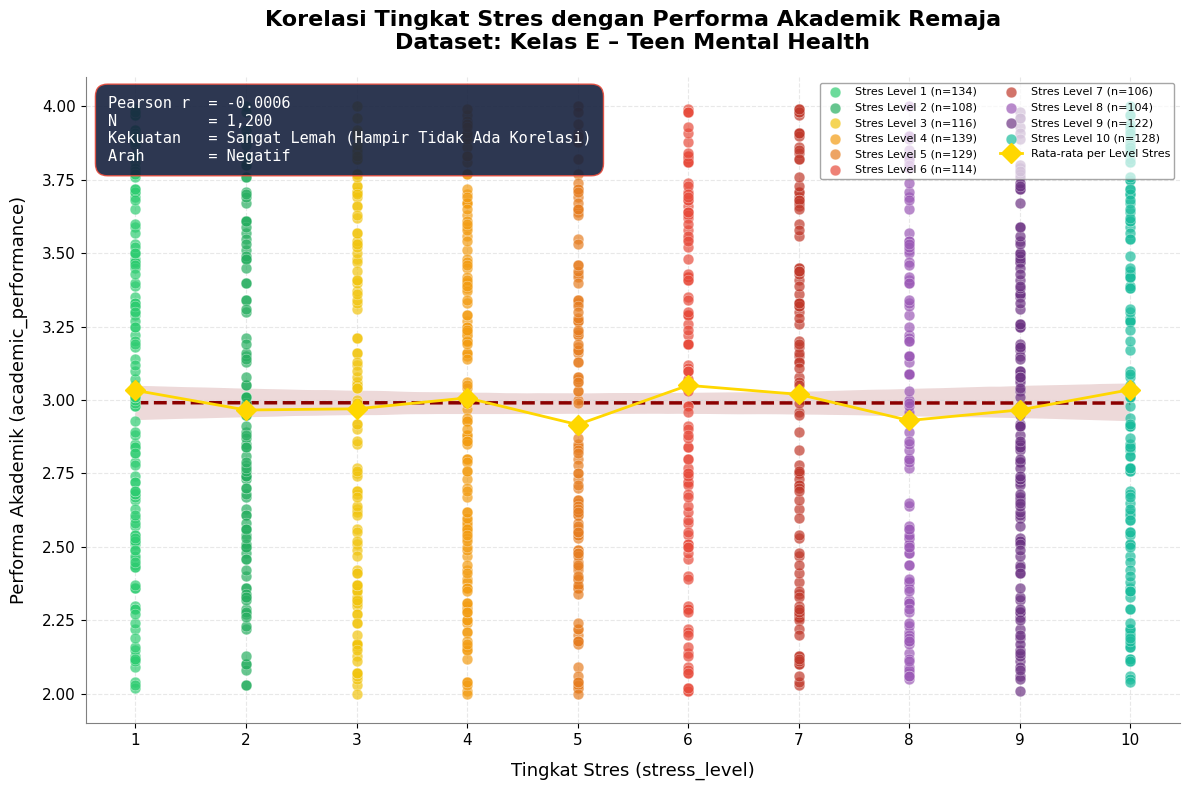

✅ Grafik berhasil disimpan!
         INTERPRETASI HASIL KORELASI
Variabel X : stress_level         (skala 1–10)
Variabel Y : academic_performance (GPA 2.0–4.0)

Koefisien Korelasi Pearson (r) = -0.0006
Kekuatan Korelasi              : Sangat Lemah (Hampir Tidak Ada Korelasi)
Arah Korelasi                  : Negatif

Kesimpulan:
  Tingkat stres remaja tidak memiliki hubungan yang
  signifikan terhadap performa akademik pada dataset
  Kelas E. Faktor lain kemungkinan lebih berpengaruh.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
df = pd.read_csv('Kelas E_Teen Mental Health.csv')
print(f'Jumlah data: {len(df)} baris')
print(df[['stress_level', 'academic_performance']].describe())
# ----------------------------------------------------------
# 2. HITUNG KORELASI (pandas)
# ----------------------------------------------------------
korelasi = df['stress_level'].corr(df['academic_performance'])

abs_r = abs(korelasi)
if abs_r < 0.1:
    kekuatan = 'Sangat Lemah (Hampir Tidak Ada Korelasi)'
elif abs_r < 0.3:
    kekuatan = 'Lemah'
elif abs_r < 0.5:
    kekuatan = 'Sedang'
elif abs_r < 0.7:
    kekuatan = 'Kuat'
else:
    kekuatan = 'Sangat Kuat'

arah = 'Negatif' if korelasi < 0 else 'Positif'

print(f'Koefisien Korelasi Pearson (r) : {korelasi:.4f}')
print(f'Kekuatan Korelasi              : {kekuatan}')
print(f'Arah Korelasi                  : {arah}')
# ----------------------------------------------------------
# 3. SCATTER PLOT (GRAFIK 3 - KATEGORI C)
# Menggunakan pendekatan objek: ax = axes[x, y]
# ----------------------------------------------------------

# Warna berbeda untuk tiap level stres 1–10
palette_10 = [
    '#2ECC71',  # 1  – hijau terang
    '#27AE60',  # 2  – hijau tua
    '#F1C40F',  # 3  – kuning
    '#F39C12',  # 4  – oranye muda
    '#E67E22',  # 5  – oranye
    '#E74C3C',  # 6  – merah muda
    '#C0392B',  # 7  – merah tua
    '#9B59B6',  # 8  – ungu
    '#6C3483',  # 9  – ungu tua
    '#1ABC9C',  # 10 – teal
]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
fig.patch.set_facecolor('white') # Changed from '#0F0F1A'
ax.set_facecolor('white') # Changed from '#1A1A2E'

# Plot titik per level stres dengan warna berbeda
for level in range(1, 11):
    subset = df[df['stress_level'] == level]
    ax.scatter(
        subset['stress_level'],
        subset['academic_performance'],
        color=palette_10[level - 1],
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidths=0.3,
        label=f'Stres Level {level} (n={len(subset)})',
        zorder=3
    )

# Garis regresi + confidence interval (seaborn)
sns.regplot(
    data=df,
    x='stress_level',
    y='academic_performance',
    scatter=False,
    ci=95,
    line_kws={
        'color': 'darkred', # Changed from '#F8F9FA'
        'linewidth': 2.5,
        'linestyle': '--',
        'label': 'Regresi Linear (seaborn)'
    },
    color='lightgray', # Changed from '#F8F9FA' (confidence interval fill)
    ax=ax
)

# Titik rata-rata GPA per level stres (highlight berlian emas)
mean_per_stress = df.groupby('stress_level')['academic_performance'].mean()
ax.plot(
    mean_per_stress.index,
    mean_per_stress.values,
    color='#FFD700',
    marker='D',
    markersize=10,
    linewidth=2,
    label='Rata-rata per Level Stres',
    zorder=5
)

# Kotak anotasi statistik
textstr = (
    f'Pearson r  = {korelasi:.4f}\n'
    f'N          = {len(df):,}\n'
    f'Kekuatan   = {kekuatan}\n'
    f'Arah       = {arah}'
)
props = dict(boxstyle='round,pad=0.8', facecolor='#16213E',
             edgecolor='#E74C3C', alpha=0.9)
ax.text(
    0.02, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=props,
    color='white', # Retained white for contrast with the dark box
    fontfamily='monospace'
)

# Label dan judul
ax.set_xlabel('Tingkat Stres (stress_level)', fontsize=13,
              color='black', labelpad=10) # Changed from '#E0E0E0'
ax.set_ylabel('Performa Akademik (academic_performance)', fontsize=13,
              color='black', labelpad=10) # Changed from '#E0E0E0'
ax.set_title(
    'Korelasi Tingkat Stres dengan Performa Akademik Remaja\n'
    'Dataset: Kelas E – Teen Mental Health',
    fontsize=16, color='black', fontweight='bold', pad=20 # Changed from 'white'
)

# Sumbu dan grid
ax.set_xticks(range(1, 11))
ax.set_xticklabels([str(i) for i in range(1, 11)],
                   color='black', fontsize=11) # Changed from '#CCCCCC'
ax.tick_params(axis='y', colors='black', labelsize=11) # Changed from '#CCCCCC'
ax.grid(True, linestyle='--', alpha=0.5, color='lightgray') # Changed from 'white'
ax.spines['bottom'].set_color('gray') # Changed from '#444'
ax.spines['left'].set_color('gray') # Changed from '#444'
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(
    loc='upper right',
    fontsize=8,
    ncol=2,
    framealpha=0.7, # Increased framealpha for better visibility
    facecolor='white', # Changed from '#1A1A2E'
    edgecolor='gray', # Changed from '#555'
    labelcolor='black' # Changed from 'white'
)

plt.tight_layout()
plt.savefig('scatter_stress_akademik.png', dpi=150,
            bbox_inches='tight', facecolor='white') # Changed from '#0F0F1A'
plt.show()
print('✅ Grafik berhasil disimpan!')
# ----------------------------------------------------------
# 4. INTERPRETASI & KESIMPULAN
# ----------------------------------------------------------
print('=' * 60)
print('         INTERPRETASI HASIL KORELASI')
print('=' * 60)
print(f'Variabel X : stress_level         (skala 1–10)')
print(f'Variabel Y : academic_performance (GPA 2.0–4.0)')
print()
print(f'Koefisien Korelasi Pearson (r) = {korelasi:.4f}')
print(f'Kekuatan Korelasi              : {kekuatan}')
print(f'Arah Korelasi                  : {arah}')
print()
print('Kesimpulan:')
print('  Tingkat stres remaja tidak memiliki hubungan yang')
print('  signifikan terhadap performa akademik pada dataset')
print('  Kelas E. Faktor lain kemungkinan lebih berpengaruh.')
print('=' * 60)

4. Line Plot: Pengaruh Waktu Layar Terhadap Tingkat Kecemasan
Pertanyaan: Apakah ada korelasi antara durasi penggunaan media sosial harian dengan tingkat kecemasan?



Total data: 1200 baris
Rentang usia : 13 – 19 tahun
Rentang sleep: 4.0 – 9.0 jam

Jumlah data per kategori:
kategori_usia
Remaja Awal\n(13–14 th)      353
Remaja Tengah\n(15–16 th)    343
Remaja Akhir\n(17–19 th)     504
Name: count, dtype: int64

Statistik sleep_hours per kategori:
                           count   mean    std  min  25%  50%  75%  max
kategori_usia                                                          
Remaja Awal\n(13–14 th)    353.0  6.412  1.463  4.0  5.1  6.4  7.6  9.0
Remaja Tengah\n(15–16 th)  343.0  6.490  1.459  4.0  5.3  6.5  7.7  9.0
Remaja Akhir\n(17–19 th)   504.0  6.448  1.420  4.0  5.1  6.5  7.6  9.0


C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\1266608404.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\1266608404.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\1266608404.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(urutan, color='#444444', fontsize=11)


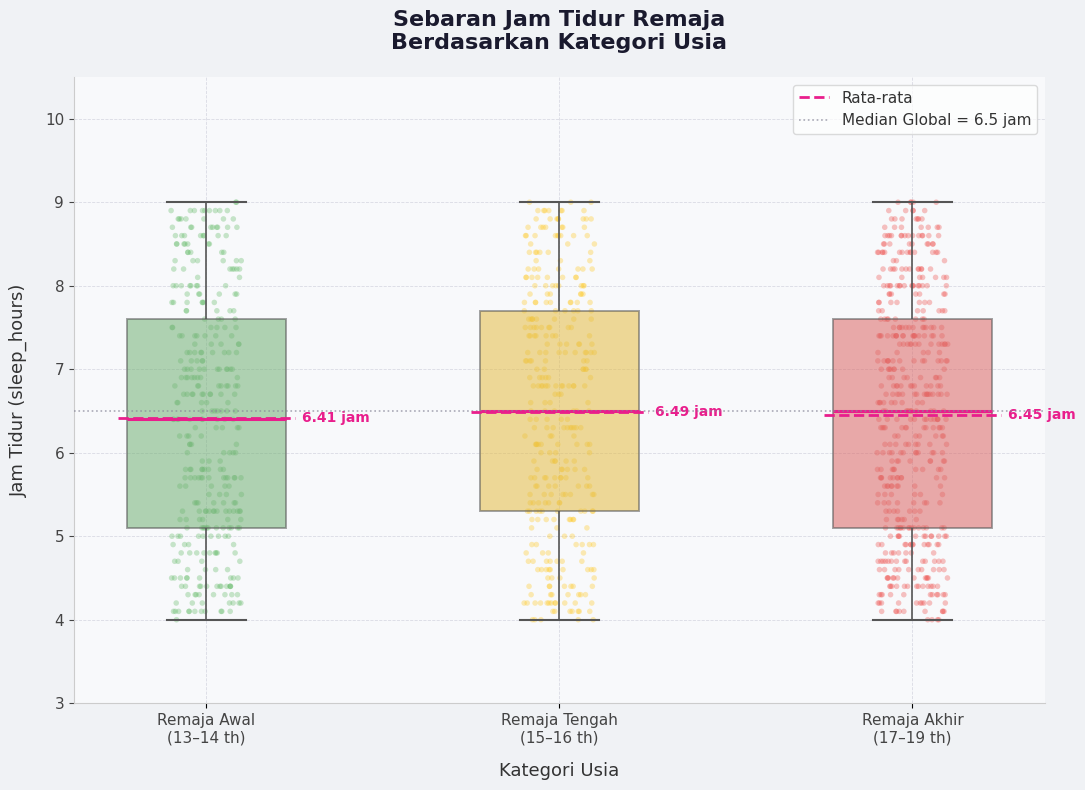

✅ Grafik berhasil disimpan!
        INTERPRETASI HASIL DISTRIBUSI
  Kategori                    Min  Median    Mean   Max
  -*50
  Remaja Awal (13–14 th)      4.0    6.40    6.41   9.0
  Remaja Tengah (15–16 th)    4.0    6.50    6.49   9.0
  Remaja Akhir (17–19 th)     4.0    6.50    6.45   9.0

  Median Global : 6.5 jam

  Keterangan boxplot:
  • Garis tengah kotak  = median
  • Kotak (IQR)         = Q1 hingga Q3
  • Garis putus pink    = rata-rata per kategori
  • Titik transparan    = sebaran data individual
  • Garis titik abu     = median global

  Kesimpulan:
  Distribusi jam tidur relatif serupa antar kelompok.
  Variasi lebar di setiap kategori menunjukkan
  kebiasaan tidur remaja sangat beragam.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
df = pd.read_csv('Kelas E_Teen Mental Health.csv')
print(f'Total data: {len(df)} baris')
print(f'Rentang usia : {df["age"].min()} – {df["age"].max()} tahun')
print(f'Rentang sleep: {df["sleep_hours"].min()} – {df["sleep_hours"].max()} jam')
# ----------------------------------------------------------
# 2. KATEGORISASI UMUR
# ----------------------------------------------------------
def kategorikan_usia(age):
    if age <= 14:
        return 'Remaja Awal\n(13–14 th)'
    elif age <= 16:
        return 'Remaja Tengah\n(15–16 th)'
    else:
        return 'Remaja Akhir\n(17–19 th)'

df['kategori_usia'] = df['age'].apply(kategorikan_usia)

urutan = [
    'Remaja Awal\n(13–14 th)',
    'Remaja Tengah\n(15–16 th)',
    'Remaja Akhir\n(17–19 th)'
]

df['kategori_usia'] = pd.Categorical(
    df['kategori_usia'], categories=urutan, ordered=True
)

print('\nJumlah data per kategori:')
print(df['kategori_usia'].value_counts().sort_index())

print('\nStatistik sleep_hours per kategori:')
print(df.groupby('kategori_usia', observed=True)['sleep_hours']
        .describe().round(3))
# ----------------------------------------------------------
# 3. BOXPLOT STYLE REFERENSI (GRAFIK 4 - KATEGORI D)
# Background terang, warna gradien hijau–kuning–merah
# Menggunakan pendekatan objek: ax = axes[x, y]
# ----------------------------------------------------------

# Palet gradien hijau–kuning–merah (mirip referensi)
warna_gradien = ['#66BB6A', '#FFCA28', '#EF5350']

fig, ax = plt.subplots(1, 1, figsize=(11, 8))
fig.patch.set_facecolor('#F0F2F5')
ax.set_facecolor('#F8F9FB')

# Strip plot dulu (titik individual transparan, seperti referensi)
sns.stripplot(
    data=df,
    x='kategori_usia',
    y='sleep_hours',
    order=urutan,
    palette=warna_gradien,
    size=4,
    alpha=0.35,
    jitter=True,
    zorder=2,
    ax=ax
)

# Boxplot di atas strip (transparan agar titik tetap terlihat)
sns.boxplot(
    data=df,
    x='kategori_usia',
    y='sleep_hours',
    order=urutan,
    palette=warna_gradien,
    width=0.45,
    linewidth=1.4,
    boxprops=dict(alpha=0.55),
    whiskerprops=dict(linewidth=1.2, color='#555555'),
    capprops=dict(linewidth=1.5, color='#555555'),
    medianprops=dict(linewidth=2.2, color='#E91E8C'),
    flierprops=dict(
        marker='o',
        markerfacecolor='#AAAAAA',
        markeredgecolor='#888888',
        markersize=4,
        alpha=0.4
    ),
    zorder=3,
    ax=ax
)

# Garis rata-rata per kategori (putus-putus pink seperti referensi)
means = df.groupby('kategori_usia', observed=True)['sleep_hours'].mean()
for i, kat in enumerate(urutan):
    ax.plot(
        [i - 0.25, i + 0.25],
        [means[kat], means[kat]],
        color='#E91E8C',
        linewidth=2,
        linestyle='--',
        zorder=5,
        label='Rata-rata' if i == 0 else ''
    )
    ax.text(
        i + 0.27,
        means[kat],
        f'{means[kat]:.2f} jam',
        va='center',
        fontsize=10,
        color='#E91E8C',
        fontweight='bold'
    )

# Garis median global putus-putus abu
median_global = df['sleep_hours'].median()
ax.axhline(
    median_global,
    color='#888899',
    linewidth=1.2,
    linestyle=':',
    alpha=0.7,
    label=f'Median Global = {median_global:.1f} jam',
    zorder=4
)

# Label dan judul
ax.set_xlabel('Kategori Usia', fontsize=13,
              color='#333333', labelpad=12)
ax.set_ylabel('Jam Tidur (sleep_hours)', fontsize=13,
              color='#333333', labelpad=12)
ax.set_title(
    'Sebaran Jam Tidur Remaja\nBerdasarkan Kategori Usia',
    fontsize=16, color='#1A1A2E',
    fontweight='bold', pad=20
)

ax.set_xticklabels(urutan, color='#444444', fontsize=11)
ax.tick_params(axis='y', colors='#444444', labelsize=11)
ax.set_ylim(3, 10.5)
ax.set_yticks([3, 4, 5, 6, 7, 8, 9, 10])

ax.grid(True, linestyle='--', linewidth=0.6,
        alpha=0.5, color='#BBBBCC', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_color('#CCCCCC')

ax.legend(
    fontsize=11,
    framealpha=0.7,
    facecolor='white',
    edgecolor='#CCCCCC',
    labelcolor='#333333',
    loc='upper right'
)

plt.tight_layout()
plt.savefig('boxplot_sleep_usia_v2.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print('✅ Grafik berhasil disimpan!')
# ----------------------------------------------------------
# 4. INTERPRETASI & KESIMPULAN
# ----------------------------------------------------------
print('=' * 58)
print('        INTERPRETASI HASIL DISTRIBUSI')
print('=' * 58)
print(f'  {"Kategori":<25} {"Min":>5} {"Median":>7} '
      f'{"Mean":>7} {"Max":>5}')
print(f'  {"-*50"}')

for kat in urutan:
    sub   = df[df['kategori_usia'] == kat]['sleep_hours']
    label = kat.replace('\n', ' ')
    print(f'  {label:<25} {sub.min():>5.1f} {sub.median():>7.2f} '
          f'{sub.mean():>7.2f} {sub.max():>5.1f}')

print(f'\n  Median Global : {median_global:.1f} jam')
print()
print('  Keterangan boxplot:')
print('  • Garis tengah kotak  = median')
print('  • Kotak (IQR)         = Q1 hingga Q3')
print('  • Garis putus pink    = rata-rata per kategori')
print('  • Titik transparan    = sebaran data individual')
print('  • Garis titik abu     = median global')
print()
print('  Kesimpulan:')
print('  Distribusi jam tidur relatif serupa antar kelompok.')
print('  Variasi lebar di setiap kategori menunjukkan')
print('  kebiasaan tidur remaja sangat beragam.')
print('=' * 58)

5. Grafik 5 (Gabungan):

Total data: 1200 baris
✅ Semua data siap


C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\3990189937.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Low', 'Medium', 'High'], color='#444444', fontsize=10)
C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\3990189937.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\3990189937.py:234: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_28136\3990189937.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat

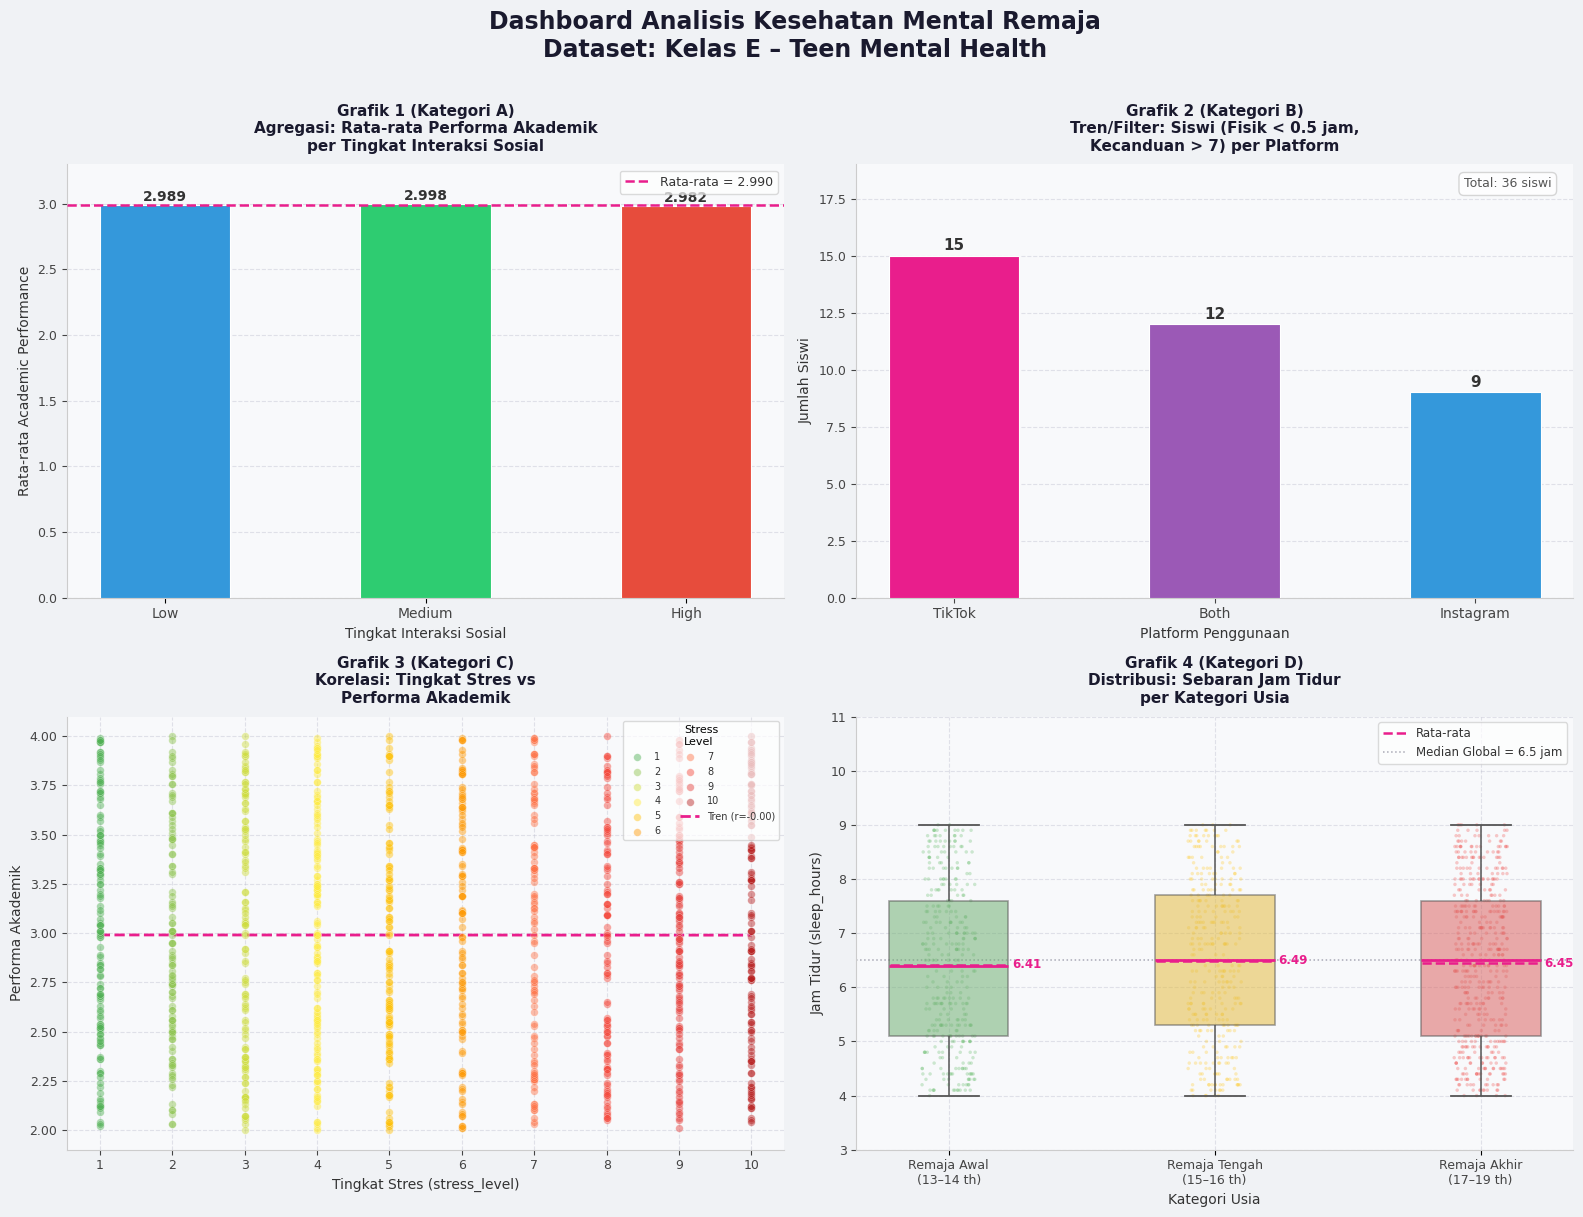

✅ Grafik 5 (Gabungan) berhasil disimpan!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------
df = pd.read_csv('Kelas E_Teen Mental Health.csv')
print(f'Total data: {len(df)} baris')
# ----------------------------------------------------------
# 2. PERSIAPAN DATA (semua grafik)
# ----------------------------------------------------------

# ── Grafik 1: Agregasi ──
agregasi = df.groupby('social_interaction_level')['academic_performance'].mean().reset_index()
agregasi.columns = ['social_interaction_level', 'rata_rata_akademik']
urutan_sosial = ['low', 'medium', 'high']
agregasi['social_interaction_level'] = pd.Categorical(
    agregasi['social_interaction_level'],
    categories=urutan_sosial, ordered=True
)
agregasi = agregasi.sort_values('social_interaction_level').reset_index(drop=True)

# ── Grafik 2: Filter/Tren ──
df_filter = df[
    (df['gender'] == 'female') &
    (df['physical_activity'] < 0.5) &
    (df['addiction_level'] > 7)
].reset_index(drop=True)
tren_platform = df_filter.groupby('platform_usage').size().reset_index()
tren_platform.columns = ['platform_usage', 'jumlah']
tren_platform = tren_platform.sort_values('jumlah', ascending=False).reset_index(drop=True)

# ── Grafik 3: Korelasi ──
korelasi = df['stress_level'].corr(df['academic_performance'])

# ── Grafik 4: Distribusi ──
def kategorikan_usia(age):
    if age <= 14:
        return 'Remaja Awal\n(13–14 th)'
    elif age <= 16:
        return 'Remaja Tengah\n(15–16 th)'
    else:
        return 'Remaja Akhir\n(17–19 th)'

df['kategori_usia'] = df['age'].apply(kategorikan_usia)
urutan_usia = [
    'Remaja Awal\n(13–14 th)',
    'Remaja Tengah\n(15–16 th)',
    'Remaja Akhir\n(17–19 th)'
]
df['kategori_usia'] = pd.Categorical(
    df['kategori_usia'], categories=urutan_usia, ordered=True
)

print('✅ Semua data siap')
# ----------------------------------------------------------
# 3. GRAFIK 5 – GABUNGAN plt.subplots(2, 2)
# Pendekatan objek: ax = axes[baris, kolom]
# ----------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F0F2F5')
fig.suptitle(
    'Dashboard Analisis Kesehatan Mental Remaja\n'
    'Dataset: Kelas E – Teen Mental Health',
    fontsize=17, fontweight='bold', color='#1A1A2E', y=1.01
)

# ═══════════════════════════════════════════════════════
# GRAFIK 1 (Kategori A) – axes[0, 0]
# Bar Chart: Rata-rata Academic Performance
# per Social Interaction Level
# ═══════════════════════════════════════════════════════
ax = axes[0, 0]
ax.set_facecolor('#F8F9FB')

warna_bar1 = ['#3498DB', '#2ECC71', '#E74C3C']
bars1 = ax.bar(
    agregasi['social_interaction_level'],
    agregasi['rata_rata_akademik'],
    color=warna_bar1,
    width=0.5,
    edgecolor='white',
    linewidth=0.8,
    zorder=3
)
for bar, nilai in zip(bars1, agregasi['rata_rata_akademik']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{nilai:.3f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#333333'
    )

rata_global = df['academic_performance'].mean()
ax.axhline(rata_global, color='#E91E8C', linewidth=1.8,
           linestyle='--', label=f'Rata-rata = {rata_global:.3f}', zorder=4)

ax.set_title('Grafik 1 (Kategori A)\nAgregasi: Rata-rata Performa Akademik\nper Tingkat Interaksi Sosial',
             fontsize=11, color='#1A1A2E', fontweight='bold', pad=10)
ax.set_xlabel('Tingkat Interaksi Sosial', fontsize=10, color='#333333')
ax.set_ylabel('Rata-rata Academic Performance', fontsize=10, color='#333333')
ax.set_xticklabels(['Low', 'Medium', 'High'], color='#444444', fontsize=10)
ax.tick_params(axis='y', colors='#444444', labelsize=9)
ax.set_ylim(0, agregasi['rata_rata_akademik'].max() + 0.3)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#BBBBCC', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_color('#CCCCCC')
ax.legend(fontsize=9, framealpha=0.7, facecolor='white',
          edgecolor='#CCCCCC', labelcolor='#333333')

# ═══════════════════════════════════════════════════════
# GRAFIK 2 (Kategori B) – axes[0, 1]
# Bar Chart: Tren Filter Remaja Perempuan
# physical_activity < 0.5, addiction_level > 7
# ═══════════════════════════════════════════════════════
ax = axes[0, 1]
ax.set_facecolor('#F8F9FB')

warna_bar2 = ['#E91E8C', '#9B59B6', '#3498DB']
bars2 = ax.bar(
    tren_platform['platform_usage'],
    tren_platform['jumlah'],
    color=warna_bar2[:len(tren_platform)],
    width=0.5,
    edgecolor='white',
    linewidth=0.8,
    zorder=3
)
for bar, nilai in zip(bars2, tren_platform['jumlah']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(nilai),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333'
    )

ax.set_title('Grafik 2 (Kategori B)\nTren/Filter: Siswi (Fisik < 0.5 jam,\nKecanduan > 7) per Platform',
             fontsize=11, color='#1A1A2E', fontweight='bold', pad=10)
ax.set_xlabel('Platform Penggunaan', fontsize=10, color='#333333')
ax.set_ylabel('Jumlah Siswi', fontsize=10, color='#333333')
ax.tick_params(axis='x', colors='#444444', labelsize=10)
ax.tick_params(axis='y', colors='#444444', labelsize=9)
ax.set_ylim(0, tren_platform['jumlah'].max() + 4)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#BBBBCC', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_color('#CCCCCC')
ax.text(0.97, 0.97, f'Total: {len(df_filter)} siswi',
        transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='#555555',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.8))

# ═══════════════════════════════════════════════════════
# GRAFIK 3 (Kategori C) – axes[1, 0]
# Scatter Plot: stress_level vs academic_performance
# ═══════════════════════════════════════════════════════
ax = axes[1, 0]
ax.set_facecolor('#F8F9FB')

warna_stress = {
    1: '#4CAF50', 2: '#8BC34A', 3: '#CDDC39', 4: '#FFEB3B',
    5: '#FFC107', 6: '#FF9800', 7: '#FF7043',
    8: '#F44336', 9: '#E53935', 10: '#B71C1C'
}
for level in range(1, 11):
    subset = df[df['stress_level'] == level]
    ax.scatter(
        subset['stress_level'],
        subset['academic_performance'],
        color=warna_stress[level],
        alpha=0.45,
        s=30,
        edgecolors='white',
        linewidths=0.3,
        label=str(level),
        zorder=3
    )

sns.regplot(
    data=df,
    x='stress_level',
    y='academic_performance',
    scatter=False,
    ci=None,
    line_kws={
        'color': '#E91E8C',
        'linewidth': 2,
        'linestyle': '--'
    },
    ax=ax
)

ax.plot([], [], color='#E91E8C', linewidth=2,
        linestyle='--', label=f'Tren (r={korelasi:.2f})')

ax.set_title('Grafik 3 (Kategori C)\nKorelasi: Tingkat Stres vs\nPerforma Akademik',
             fontsize=11, color='#1A1A2E', fontweight='bold', pad=10)
ax.set_xlabel('Tingkat Stres (stress_level)', fontsize=10, color='#333333')
ax.set_ylabel('Performa Akademik', fontsize=10, color='#333333')
ax.set_xticks(range(1, 11))
ax.tick_params(axis='x', colors='#444444', labelsize=9)
ax.tick_params(axis='y', colors='#444444', labelsize=9)
ax.grid(True, linestyle='--', alpha=0.4, color='#BBBBCC', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_color('#CCCCCC')
ax.legend(title='Stress\nLevel', fontsize=7, title_fontsize=8,
          ncol=2, framealpha=0.7, facecolor='white',
          edgecolor='#CCCCCC', labelcolor='#333333',
          loc='upper right')

# ═══════════════════════════════════════════════════════
# GRAFIK 4 (Kategori D) – axes[1, 1]
# Boxplot: Sebaran sleep_hours per kategori usia
# ═══════════════════════════════════════════════════════
ax = axes[1, 1]
ax.set_facecolor('#F8F9FB')

warna_box = ['#66BB6A', '#FFCA28', '#EF5350']

sns.stripplot(
    data=df, x='kategori_usia', y='sleep_hours',
    order=urutan_usia, palette=warna_box,
    size=2.5, alpha=0.3, jitter=True, zorder=2, ax=ax
)
sns.boxplot(
    data=df, x='kategori_usia', y='sleep_hours',
    order=urutan_usia, palette=warna_box,
    width=0.45, linewidth=1.2,
    boxprops=dict(alpha=0.55),
    whiskerprops=dict(linewidth=1.1, color='#555555'),
    capprops=dict(linewidth=1.3, color='#555555'),
    medianprops=dict(linewidth=2, color='#E91E8C'),
    flierprops=dict(marker='o', markerfacecolor='#AAAAAA',
                    markeredgecolor='#888888',
                    markersize=3, alpha=0.4),
    zorder=3, ax=ax
)

means_usia = df.groupby('kategori_usia', observed=True)['sleep_hours'].mean()
for i, kat in enumerate(urutan_usia):
    ax.plot(
        [i - 0.22, i + 0.22],
        [means_usia[kat], means_usia[kat]],
        color='#E91E8C', linewidth=1.8, linestyle='--', zorder=5,
        label='Rata-rata' if i == 0 else ''
    )
    ax.text(i + 0.24, means_usia[kat],
            f'{means_usia[kat]:.2f}',
            va='center', fontsize=8.5,
            color='#E91E8C', fontweight='bold')

median_global = df['sleep_hours'].median()
ax.axhline(median_global, color='#888899', linewidth=1.1,
           linestyle=':', alpha=0.7,
           label=f'Median Global = {median_global:.1f} jam')

ax.set_title('Grafik 4 (Kategori D)\nDistribusi: Sebaran Jam Tidur\nper Kategori Usia',
             fontsize=11, color='#1A1A2E', fontweight='bold', pad=10)
ax.set_xlabel('Kategori Usia', fontsize=10, color='#333333')
ax.set_ylabel('Jam Tidur (sleep_hours)', fontsize=10, color='#333333')
ax.set_xticklabels(
    ['Remaja Awal\n(13–14 th)',
     'Remaja Tengah\n(15–16 th)',
     'Remaja Akhir\n(17–19 th)'],
    color='#444444', fontsize=9
)
ax.tick_params(axis='y', colors='#444444', labelsize=9)
ax.set_ylim(3, 11)
ax.grid(True, linestyle='--', alpha=0.4, color='#BBBBCC', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['left'].set_color('#CCCCCC')
ax.legend(fontsize=8.5, framealpha=0.7, facecolor='white',
          edgecolor='#CCCCCC', labelcolor='#333333', loc='upper right')

# ── Simpan & Tampilkan ──
plt.tight_layout()
plt.savefig('grafik5_gabungan.png', dpi=150,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print('✅ Grafik 5 (Gabungan) berhasil disimpan!')